# FUSE Stage 0 — FLUX.1 Fill [dev] 4-bit reference hypotheses

This notebook creates **synthetic intact-reference hypotheses** from a
photograph of a damaged object. It uses the mask-conditioned
`black-forest-labs/FLUX.1-Fill-dev` pipeline: black mask pixels are
protected and white mask pixels are generated.

The result is not measured evidence or historical ground truth. FUSE
keeps several seeded alternatives, records their provenance, and
requires an explicit human selection before publishing an image to
Hunyuan.

## One-time model-access requirement

1. Sign in to Hugging Face and open
   <https://huggingface.co/black-forest-labs/FLUX.1-Fill-dev>.
2. Accept the FLUX.1 dev license/access conditions.
3. Create a Hugging Face **read** token.
4. On the host, run `export HF_TOKEN='hf_...'` before recreating the
   container. Never paste the token into this notebook or commit it.

FLUX.1 Fill [dev] uses gated, non-commercial model weights. Review the
license and the hackathon rules before use.


In [1]:
import gc
import hashlib
import importlib.metadata as metadata
import json
import os
import shutil
import sys
import time
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import torch
from diffusers import (
    BitsAndBytesConfig as DiffusersBitsAndBytesConfig,
    FluxFillPipeline,
    FluxTransformer2DModel,
)
from huggingface_hub import get_token, whoami
from IPython.display import display
from PIL import Image, ImageDraw, ImageFilter, PngImagePlugin
from transformers import (
    BitsAndBytesConfig as TransformersBitsAndBytesConfig,
    T5EncoderModel,
)

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA runtime:", torch.version.cuda)
print("Diffusers:", metadata.version("diffusers"))
print("Transformers:", metadata.version("transformers"))
print("bitsandbytes:", metadata.version("bitsandbytes"))
print(f"Host RAM: {psutil.virtual_memory().total / 2**30:.1f} GiB")

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is unavailable. Verify the NVIDIA driver, Docker NVIDIA "
        "runtime, and the container's `gpus: all` setting."
    )

print("GPU:", torch.cuda.get_device_name(0))
print(
    "GPU VRAM:",
    f"{torch.cuda.get_device_properties(0).total_memory / 2**30:.1f} GiB",
)
print("BF16 supported:", torch.cuda.is_bf16_supported())


Python: 3.11.13
PyTorch: 2.7.1+cu128
CUDA runtime: 12.8
Diffusers: 0.39.0
Transformers: 4.57.6
bitsandbytes: 0.50.1
Host RAM: 31.1 GiB
GPU: NVIDIA GeForce RTX 4080 Laptop GPU
GPU VRAM: 11.6 GiB
BF16 supported: True


## Configuration

The default polygon below is tailored to the current Pogo/Nessie image.
For another photograph, set `CUSTOM_MASK_PATH` to a same-size grayscale
PNG: **white = generate**, **black = preserve**.

A good repair mask overlaps the surviving tail by a few pixels, follows
the intended continuation, tapers toward the tip, and includes any
intended dorsal-spike protrusions. A broad rectangular mask gives the
model too much geometric freedom.


In [2]:
MODEL_ID = "black-forest-labs/FLUX.1-Fill-dev"

FUSE_ROOT = Path("/workspace") if Path("/workspace/data").exists() else Path.cwd().resolve()
DATA_ROOT = FUSE_ROOT / "data"

INPUT_IMAGE = DATA_ROOT / "scenes" / "global" / "reference" / "pogo_incomplete.png"
PREVIOUS_SYNTHETIC = DATA_ROOT / "scenes" / "global" / "reference" / "pogo_complete.png"

# Optional same-size grayscale PNG. White is filled; black is protected.
CUSTOM_MASK_PATH = None

# Normalized (x, y) outline for the present vertical missing tail tip.
# It deliberately overlaps the visible fracture and contains one small
# outward notch where a dorsal spike may continue.
MASK_POLYGON_NORMALIZED = [
    (0.764, 0.462),
    (0.770, 0.420),
    (0.772, 0.360),
    (0.760, 0.330),
    (0.776, 0.310),
    (0.781, 0.250),
    (0.790, 0.190),
    (0.801, 0.250),
    (0.807, 0.330),
    (0.811, 0.410),
    (0.815, 0.462),
]

# The model receives the binary mask. Feathering is used only when the
# generated crop is composited back into the exact source photograph.
FEATHER_RADIUS_PX = 8

# A padded crop makes the fracture larger in model space while retaining
# enough surrounding tail/back context to infer glaze, lighting and form.
AUTO_CROP_TO_MASK = True
CROP_PADDING_PX = 160
MODEL_MAX_SIDE = 640
MODEL_MAX_AREA = 640 * 640
MODEL_SIZE_MULTIPLE = 16

PROMPT = """
Fill only the white masked region to reconstruct the missing tail tip of
exactly the same glossy hand-painted ceramic green dragon figurine.
Continue the surviving green tail directly through the visible fracture
in its current nearly vertical upward tangent. The new part must be one
continuous green ceramic volume with matching starting thickness, glaze,
highlights, camera perspective and a gradual natural taper. Continue one
small dark-navy dorsal spike along the outer edge, following the existing
spike rhythm. End in an integrated moderately pointed green ceramic tip.
The junction must look physically continuous and the black background
must remain black. Do not attach a cap, cone, horn, pencil point, white
object or navy terminal cap. Do not redesign the dragon or alter any
protected part of the photograph.
""".strip()

# Start with one seed for a smoke test, then restore all four.
SEEDS = [17]
SELECTED_SEED = 17

# Fill's official example uses 50 steps and guidance 30. Thirty steps is
# the practical 12 GB smoke-test default; use 50 for final candidates.
NUM_INFERENCE_STEPS = 30
GUIDANCE_SCALE = 30.0
MAX_SEQUENCE_LENGTH = 128

# "model" is the normal 12 GB path. Use "sequential" only after OOM;
# it lowers peak VRAM but is substantially slower.
OFFLOAD_MODE = "model"

RUN_NAME = "reference_fill_" + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
RUN_DIR = DATA_ROOT / "flux_outputs" / "runs" / RUN_NAME
RAW_DIR = RUN_DIR / "raw_candidates"
CANDIDATE_DIR = RUN_DIR / "constrained_candidates"
SELECTED_DIR = RUN_DIR / "selected"

# Publishing is always a separate, explicit human decision.
PUBLISH_TO_HUNYUAN = False
HUNYUAN_INPUT = DATA_ROOT / "scenes" / "global" / "reference" / "pogo_complete.png"

print("Input:", INPUT_IMAGE)
print("Run:", RUN_DIR)
print("Seeds:", SEEDS)
print("Offload mode:", OFFLOAD_MODE)


Input: /workspace/data/scenes/global/reference/pogo_incomplete.png
Run: /workspace/data/flux_outputs/runs/reference_fill_20260816T140151Z
Seeds: [17]
Offload mode: model


Damaged input size: (1280, 720)
Damaged input SHA-256: 5d5b4364ca2d156547ad85c8329e2206b22532796f427dd33898075dfee7cef4


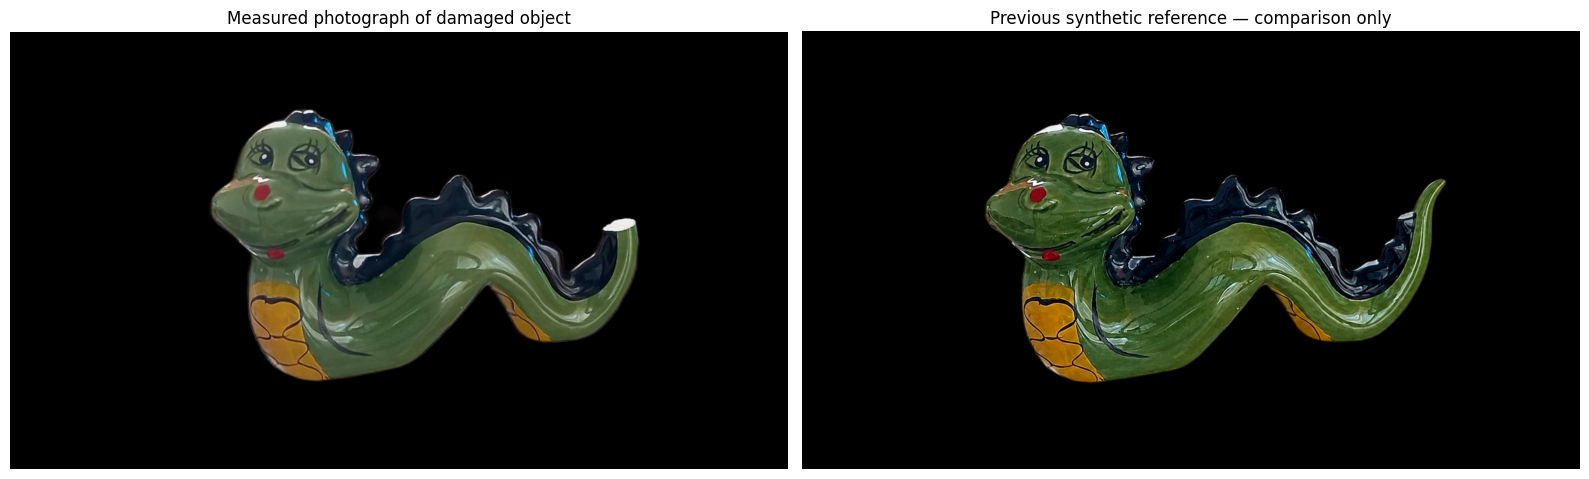

In [3]:
for folder in (RAW_DIR, CANDIDATE_DIR, SELECTED_DIR):
    folder.mkdir(parents=True, exist_ok=True)

if not INPUT_IMAGE.exists():
    raise FileNotFoundError(f"Place the damaged photograph at {INPUT_IMAGE}")

source_image = Image.open(INPUT_IMAGE).convert("RGB")
shutil.copy2(INPUT_IMAGE, RUN_DIR / "pogo_incomplete.png")

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

print("Damaged input size:", source_image.size)
print("Damaged input SHA-256:", sha256_file(INPUT_IMAGE))

if PREVIOUS_SYNTHETIC.exists():
    previous = Image.open(PREVIOUS_SYNTHETIC).convert("RGB")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].imshow(source_image)
    axes[0].set_title("Measured photograph of damaged object")
    axes[1].imshow(previous)
    axes[1].set_title("Previous synthetic reference — comparison only")
    for axis in axes:
        axis.axis("off")
    plt.tight_layout()
    plt.show()
else:
    display(source_image)
    print("No previous synthetic comparison image was supplied; this is fine.")


/tmp/ipykernel_6720/2512405027.py:34: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  feather_mask = Image.fromarray(feather_array, mode="L")


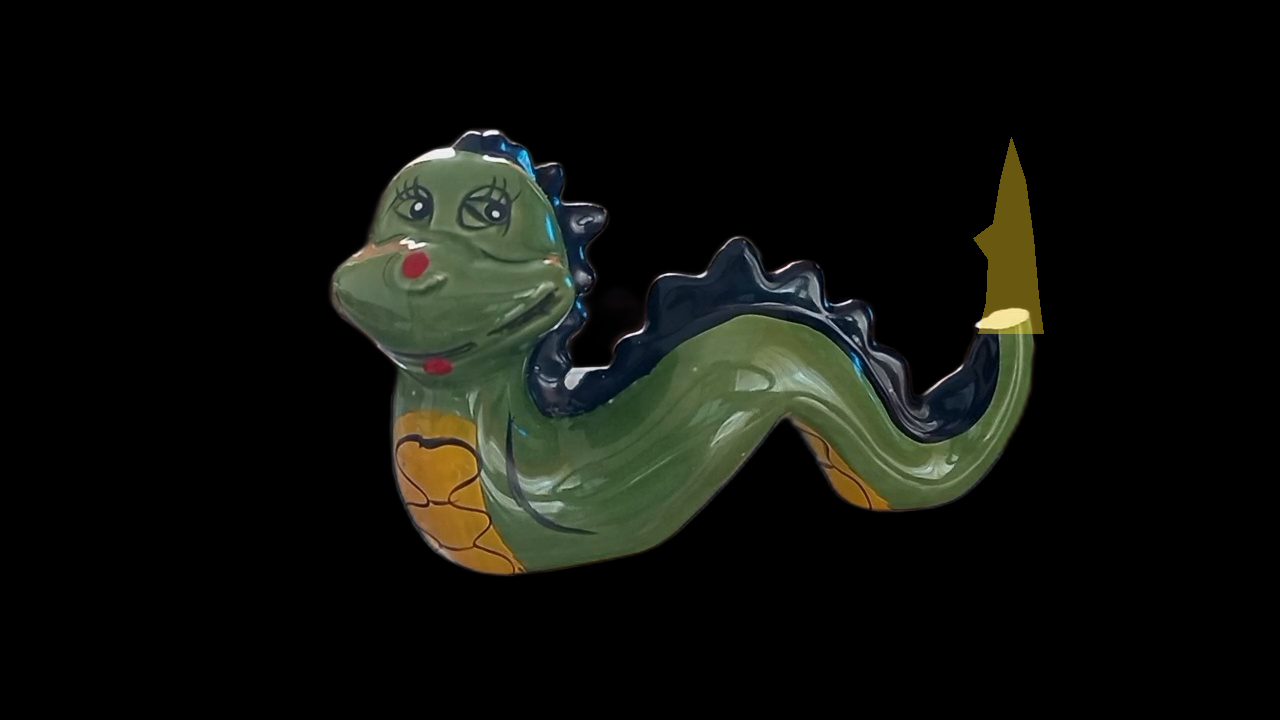

Editable fraction: 0.86%
Yellow = model-generated region; everything else is pixel-locked.


In [4]:
width, height = source_image.size

if CUSTOM_MASK_PATH is not None:
    custom_path = Path(CUSTOM_MASK_PATH)
    if not custom_path.exists():
        raise FileNotFoundError(custom_path)
    binary_mask = Image.open(custom_path).convert("L")
    if binary_mask.size != source_image.size:
        raise ValueError("The custom mask must exactly match the input image dimensions.")
    binary_mask = binary_mask.point(lambda value: 255 if value >= 128 else 0)
else:
    binary_mask = Image.new("L", source_image.size, 0)
    polygon_px = [
        (round(x * width), round(y * height))
        for x, y in MASK_POLYGON_NORMALIZED
    ]
    ImageDraw.Draw(binary_mask).polygon(polygon_px, fill=255)

mask_array = np.asarray(binary_mask, dtype=np.uint8)
editable = mask_array > 0
editable_fraction = float(editable.mean())
if not 0.001 <= editable_fraction <= 0.35:
    raise ValueError(
        f"Mask covers {editable_fraction:.2%} of the image; inspect it before generation."
    )

# Feather inward only. No generated pixel can leak outside the authority mask.
blurred = np.asarray(
    binary_mask.filter(ImageFilter.GaussianBlur(FEATHER_RADIUS_PX)),
    dtype=np.uint8,
).copy()
feather_array = blurred.copy()
feather_array[~editable] = 0
feather_mask = Image.fromarray(feather_array, mode="L")

binary_mask.save(RUN_DIR / "restoration_mask_binary.png")
feather_mask.save(RUN_DIR / "restoration_mask_feathered.png")

source_rgba = source_image.convert("RGBA")
yellow = Image.new("RGBA", source_image.size, (255, 215, 40, 0))
yellow.putalpha(binary_mask.point(lambda value: 105 if value else 0))
overlay = Image.alpha_composite(source_rgba, yellow)
overlay.save(RUN_DIR / "mask_overlay.png")

display(overlay)
print(f"Editable fraction: {editable_fraction:.2%}")
print("Yellow = model-generated region; everything else is pixel-locked.")


**Stop here and inspect the yellow region.** It should begin slightly
inside the surviving tail, follow the desired continuation and taper to
a tip. If it resembles a broad rectangle, replace it with a carefully
drawn `CUSTOM_MASK_PATH` before loading the 12B model.


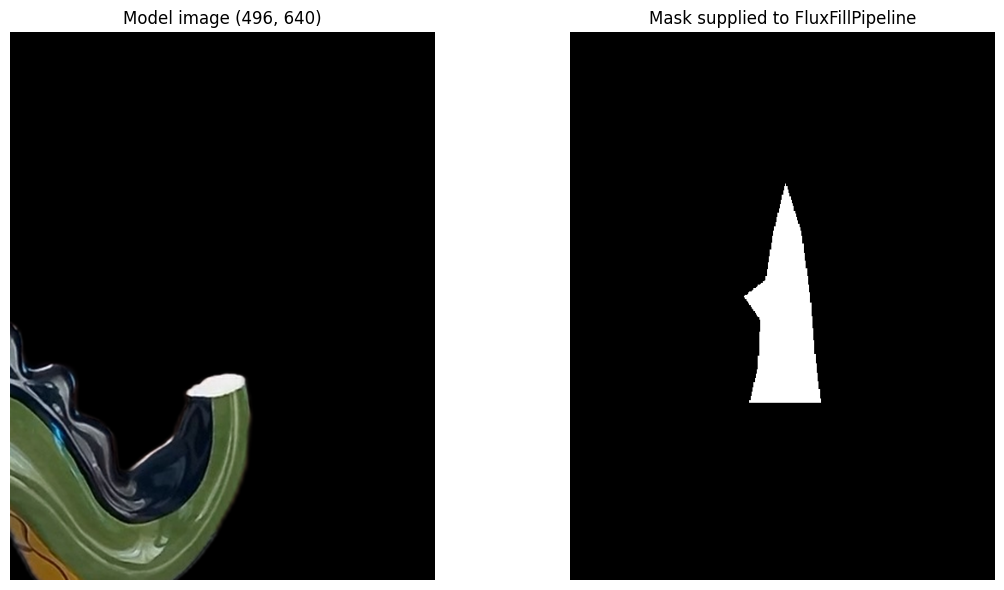

Full image size: (1280, 720)
Crop box: (813, 0, 1204, 494)
Crop size: (391, 494)
Model working size: (496, 640)


In [5]:
def padded_mask_box(mask: Image.Image, padding: int) -> tuple[int, int, int, int]:
    bbox = mask.getbbox()
    if bbox is None:
        raise ValueError("The restoration mask is empty.")
    left, top, right, bottom = bbox
    image_width, image_height = mask.size
    return (
        max(0, left - padding),
        max(0, top - padding),
        min(image_width, right + padding),
        min(image_height, bottom + padding),
    )

def model_dimensions(
    size: tuple[int, int],
    max_area: int,
    max_side: int,
    multiple: int,
) -> tuple[int, int]:
    crop_width, crop_height = size
    scale = min(
        (max_area / (crop_width * crop_height)) ** 0.5,
        max_side / max(crop_width, crop_height),
        2.0,
    )
    model_width = max(multiple, int(crop_width * scale) // multiple * multiple)
    model_height = max(multiple, int(crop_height * scale) // multiple * multiple)
    return model_width, model_height

crop_box = (
    padded_mask_box(binary_mask, CROP_PADDING_PX)
    if AUTO_CROP_TO_MASK
    else (0, 0, source_image.width, source_image.height)
)
source_crop = source_image.crop(crop_box)
mask_crop = binary_mask.crop(crop_box)
working_size = model_dimensions(
    source_crop.size,
    MODEL_MAX_AREA,
    MODEL_MAX_SIDE,
    MODEL_SIZE_MULTIPLE,
)
working_source = source_crop.resize(working_size, Image.Resampling.LANCZOS)
working_mask = mask_crop.resize(working_size, Image.Resampling.NEAREST)

working_source.save(RUN_DIR / "model_input_crop.png")
working_mask.save(RUN_DIR / "model_input_mask.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(working_source)
axes[0].set_title(f"Model image {working_size}")
axes[1].imshow(working_mask, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Mask supplied to FluxFillPipeline")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

print("Full image size:", source_image.size)
print("Crop box:", crop_box)
print("Crop size:", source_crop.size)
print("Model working size:", working_size)


## Load the gated model in NF4 4-bit

Both the 12B Fill transformer and the large T5 text encoder are loaded
in bitsandbytes NF4 with double quantization. Other components stay in
BF16. The persistent cache avoids repeating the large download.

Do not delete the cache after an interrupted download; rerunning this
cell can reuse verified shards.


In [6]:
hf_token = os.environ.get("HF_TOKEN") or get_token()
if not hf_token:
    raise RuntimeError(
        "No Hugging Face token is available. Accept access for "
        f"{MODEL_ID}, export HF_TOKEN on the host, and recreate the container."
    )

account = whoami(token=hf_token)
print("Authenticated Hugging Face account:", account.get("name", "unknown"))

gc.collect()
torch.cuda.empty_cache()

transformer_quantization = DiffusersBitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

text_quantization = TransformersBitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

# Load and quantize T5 entirely on CPU.
# bitsandbytes 0.50.1 supports its multi-backend CPU path.
print("Loading T5 encoder in 4-bit on CPU...")

text_encoder_2 = T5EncoderModel.from_pretrained(
    MODEL_ID,
    subfolder="text_encoder_2",
    quantization_config=text_quantization,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    device_map={"": "cpu"},
    token=hf_token,
)

gc.collect()
torch.cuda.empty_cache()

# Diffusers performs the transformer quantization on CUDA.
print("Loading FLUX transformer in 4-bit on CUDA...")

transformer = FluxTransformer2DModel.from_pretrained(
    MODEL_ID,
    subfolder="transformer",
    quantization_config=transformer_quantization,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    token=hf_token,
)

# Immediately free GPU memory before constructing the complete pipeline.
print("Moving quantized transformer to CPU...")
transformer.to("cpu")

gc.collect()
torch.cuda.empty_cache()

print(
    "VRAM after staged loading:",
    f"{torch.cuda.memory_allocated() / 2**30:.2f} GiB",
)

pipe = FluxFillPipeline.from_pretrained(
    MODEL_ID,
    transformer=transformer,
    text_encoder_2=text_encoder_2,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    token=hf_token,
)

if getattr(pipe, "hf_device_map", None) is not None:
    pipe.reset_device_map()

#if OFFLOAD_MODE == "sequential":
#    pipe.enable_sequential_cpu_offload(device="cuda")
#elif OFFLOAD_MODE == "model":
#    pipe.enable_model_cpu_offload(device="cuda")
#else:
#    raise ValueError("OFFLOAD_MODE must be 'model' or 'sequential'.")

assert OFFLOAD_MODE == "model"

pipe.enable_model_cpu_offload(device="cuda")
print("Installed model CPU offload")


pipe.vae.enable_tiling()
pipe.vae.enable_slicing()
pipe.set_progress_bar_config(disable=False)

print("Pipeline loaded successfully.")



def footprint_gib(module) -> float | None:
    getter = getattr(module, "get_memory_footprint", None)
    return None if getter is None else getter() / 2**30

print("Pipeline:", type(pipe).__name__)
print("Model:", MODEL_ID)
print("Offload mode:", OFFLOAD_MODE)
print("Transformer reports 4-bit:", getattr(transformer, "is_loaded_in_4bit", False))
print("T5 reports 4-bit:", getattr(text_encoder_2, "is_loaded_in_4bit", False))
print("Transformer parameter footprint GiB:", footprint_gib(transformer))
print("T5 parameter footprint GiB:", footprint_gib(text_encoder_2))


`torch_dtype` is deprecated! Use `dtype` instead!


Authenticated Hugging Face account: yuliadm-hf
Loading T5 encoder in 4-bit on CPU...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading FLUX transformer in 4-bit on CUDA...


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Moving quantized transformer to CPU...
VRAM after staged loading: 0.00 GiB


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


Installed model CPU offload
Pipeline loaded successfully.
Pipeline: FluxFillPipeline
Model: black-forest-labs/FLUX.1-Fill-dev
Offload mode: model
Transformer reports 4-bit: True
T5 reports 4-bit: True
Transformer parameter footprint GiB: 5.546793103218079
T5 parameter footprint GiB: 5.682994842529297


In [7]:



hook_types = set()

for component_name in (
    "text_encoder",
    "text_encoder_2",
    "transformer",
    "vae",
):
    component = getattr(pipe, component_name, None)
    if component is None:
        continue

    for module in component.modules():
        hook = getattr(module, "_hf_hook", None)
        if hook is not None:
            hook_types.add(type(hook).__name__)

print("Installed hook types:", sorted(hook_types))

assert "AlignDevicesHook" not in hook_types, (
    "Sequential-offload hooks are still installed. Restart the kernel "
    "and rebuild the pipeline using model CPU offload."
)














source_np = np.asarray(source_image, dtype=np.uint8)
alpha = np.asarray(feather_mask, dtype=np.float32)[..., None] / 255.0
candidate_records = []
constrained_images = {}

crop_left, crop_top, crop_right, crop_bottom = crop_box

for seed in SEEDS:
    raw_path = RAW_DIR / f"seed_{seed:06d}_raw_full.png"
    constrained_path = CANDIDATE_DIR / f"seed_{seed:06d}_intact_hypothesis.png"

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    generator = torch.Generator(device="cpu").manual_seed(seed)
    started = time.perf_counter()

    with torch.inference_mode():
        generated_working = pipe(
            prompt=PROMPT,
            image=working_source,
            mask_image=working_mask,
            height=working_size[1],
            width=working_size[0],
            guidance_scale=GUIDANCE_SCALE,
            num_inference_steps=NUM_INFERENCE_STEPS,
            max_sequence_length=MAX_SEQUENCE_LENGTH,
            generator=generator,
        ).images[0].convert("RGB")

    torch.cuda.synchronize()
    elapsed = time.perf_counter() - started
    peak_vram_gib = torch.cuda.max_memory_allocated() / 2**30

    generated_crop = generated_working.resize(source_crop.size, Image.Resampling.LANCZOS)
    raw_full = source_image.copy()
    raw_full.paste(generated_crop, (crop_left, crop_top))
    raw_full.save(raw_path)

    generated_np = np.asarray(raw_full, dtype=np.uint8)
    blended = np.rint(
        source_np.astype(np.float32) * (1.0 - alpha)
        + generated_np.astype(np.float32) * alpha
    ).clip(0, 255).astype(np.uint8)

    # Absolute evidence boundary: protected pixels are copied byte-for-byte.
    blended[~editable] = source_np[~editable]
    constrained = Image.fromarray(blended, mode="RGB")

    png_info = PngImagePlugin.PngInfo()
    png_info.add_text("fuse_asset_type", "synthetic_intact_reference_hypothesis")
    png_info.add_text("fuse_model", MODEL_ID)
    png_info.add_text("fuse_pipeline", "FluxFillPipeline")
    png_info.add_text("fuse_quantization", "NF4 4-bit double-quant")
    png_info.add_text("fuse_seed", str(seed))
    png_info.add_text("fuse_source_sha256", sha256_file(INPUT_IMAGE))
    constrained.save(constrained_path, pnginfo=png_info)

    constrained_np = np.asarray(constrained, dtype=np.uint8)
    outside_difference = np.abs(
        constrained_np.astype(np.int16) - source_np.astype(np.int16)
    )[~editable]
    inside_difference = np.abs(
        constrained_np.astype(np.int16) - source_np.astype(np.int16)
    )[editable]

    candidate_records.append(
        {
            "seed": int(seed),
            "raw_path": str(raw_path),
            "constrained_path": str(constrained_path),
            "elapsed_seconds": elapsed,
            "peak_vram_gib": peak_vram_gib,
            "outside_mask_max_abs_difference": int(outside_difference.max(initial=0)),
            "inside_mask_mean_abs_difference": float(inside_difference.mean()),
        }
    )
    constrained_images[seed] = constrained
    print(
        f"seed={seed} time={elapsed:.1f}s peak_vram={peak_vram_gib:.2f} GiB "
        f"outside_max={candidate_records[-1]['outside_mask_max_abs_difference']}"
    )
    gc.collect()
    torch.cuda.empty_cache()

records_frame = pd.DataFrame(candidate_records)
display(records_frame)

if not (records_frame["outside_mask_max_abs_difference"] == 0).all():
    raise AssertionError("At least one candidate changed protected source pixels.")


Token indices sequence length is longer than the specified maximum sequence length for this model (154 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['small dark - navy dorsal spike along the outer edge, following the existing spike rhythm. end in an integrated moderately pointed green ceramic tip. the junction must look physically continuous and the black background must remain black. do not attach a cap, cone, horn, pencil point, white object or navy terminal cap. do not redesign the dragon or alter any protected part of the photograph.']


Installed hook types: ['CpuOffload']


The following part of your input was truncated because `max_sequence_length` is set to  128 tokens: ['. Continue one small dark-navy dorsal spike along the outer edge, following the existing spike rhythm. End in an integrated moderately pointed green ceramic tip. The junction must look physically continuous and the black background must remain black. Do not attach a cap, cone, horn, pencil point, white object or navy terminal cap. Do not redesign the dragon or alter any protected part of the photograph.']


  0%|          | 0/30 [00:00<?, ?it/s]

seed=17 time=28.9s peak_vram=6.36 GiB outside_max=0


/tmp/ipykernel_6720/2864441578.py:84: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  constrained = Image.fromarray(blended, mode="RGB")


,seed,raw_path,constrained_path,elapsed_seconds,peak_vram_gib,outside_mask_max_abs_difference,inside_mask_mean_abs_difference
0,17,/workspace/data/flux_outputs/runs/reference_fi...,/workspace/data/flux_outputs/runs/reference_fi...,28.876166,6.358184,0,51.22716


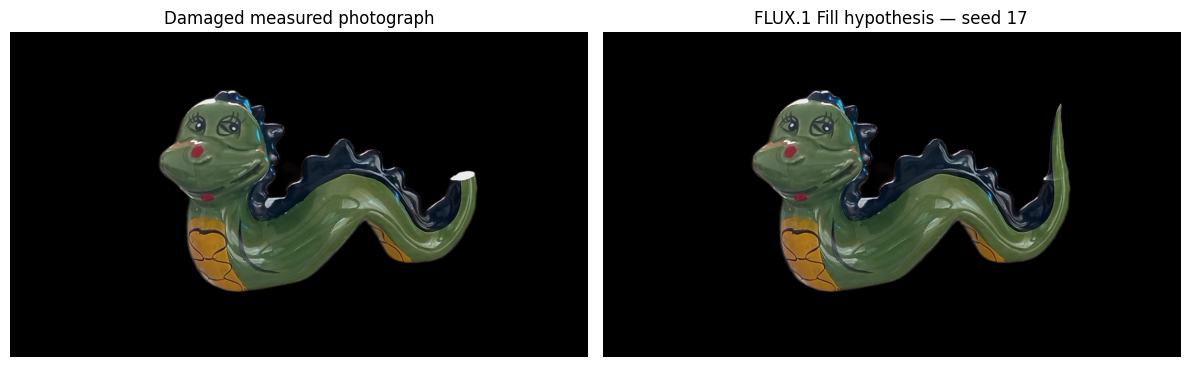

Candidate grid: /workspace/data/flux_outputs/runs/reference_fill_20260816T140151Z/candidate_grid.png


In [8]:
figure_columns = min(3, len(SEEDS) + 1)
figure_rows = int(np.ceil((len(SEEDS) + 1) / figure_columns))
fig, axes = plt.subplots(figure_rows, figure_columns, figsize=(6 * figure_columns, 5 * figure_rows))
axes = np.atleast_1d(axes).reshape(-1)

axes[0].imshow(source_image)
axes[0].set_title("Damaged measured photograph")
axes[0].axis("off")

for axis, seed in zip(axes[1:], SEEDS):
    axis.imshow(constrained_images[seed])
    axis.set_title(f"FLUX.1 Fill hypothesis — seed {seed}")
    axis.axis("off")

for axis in axes[len(SEEDS) + 1:]:
    axis.axis("off")

plt.tight_layout()
candidate_grid_path = RUN_DIR / "candidate_grid.png"
plt.savefig(candidate_grid_path, dpi=160, bbox_inches="tight")
plt.show()
print("Candidate grid:", candidate_grid_path)


/tmp/ipykernel_6720/4279838867.py:13: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  disagreement_image = Image.fromarray(disagreement_rgb, mode="RGB")


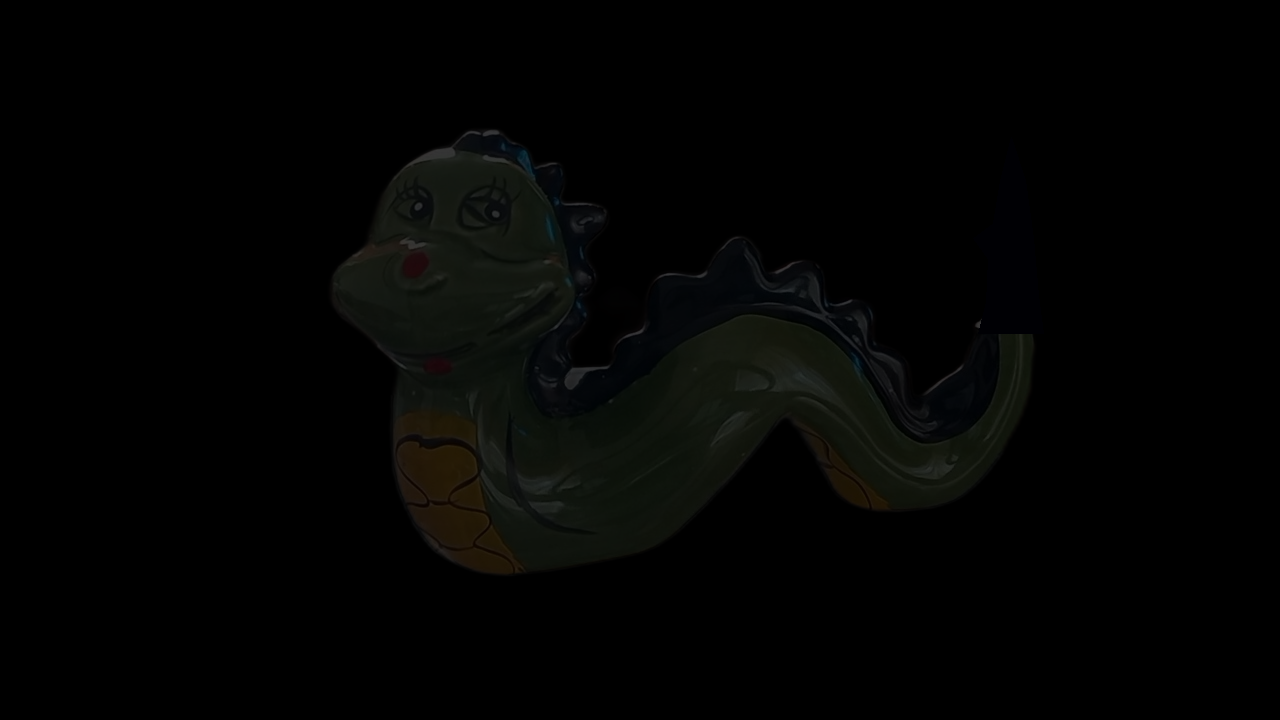

Bright pixels indicate disagreement among generated hypotheses.
This is an uncertainty proxy, not a calibrated probability.


In [9]:
candidate_stack = np.stack(
    [np.asarray(constrained_images[seed], dtype=np.float32) for seed in SEEDS],
    axis=0,
)
disagreement = candidate_stack.var(axis=0).mean(axis=2)
editable_values = disagreement[editable]
scale = max(float(np.percentile(editable_values, 99)), 1e-6)
normalized = np.clip(disagreement / scale, 0.0, 1.0)

magma = plt.get_cmap("magma")(normalized)[..., :3]
disagreement_rgb = np.rint(magma * 255).astype(np.uint8)
disagreement_rgb[~editable] = np.rint(source_np[~editable] * 0.22).astype(np.uint8)
disagreement_image = Image.fromarray(disagreement_rgb, mode="RGB")
disagreement_path = RUN_DIR / "candidate_disagreement.png"
disagreement_image.save(disagreement_path)

display(disagreement_image)
print("Bright pixels indicate disagreement among generated hypotheses.")
print("This is an uncertainty proxy, not a calibrated probability.")


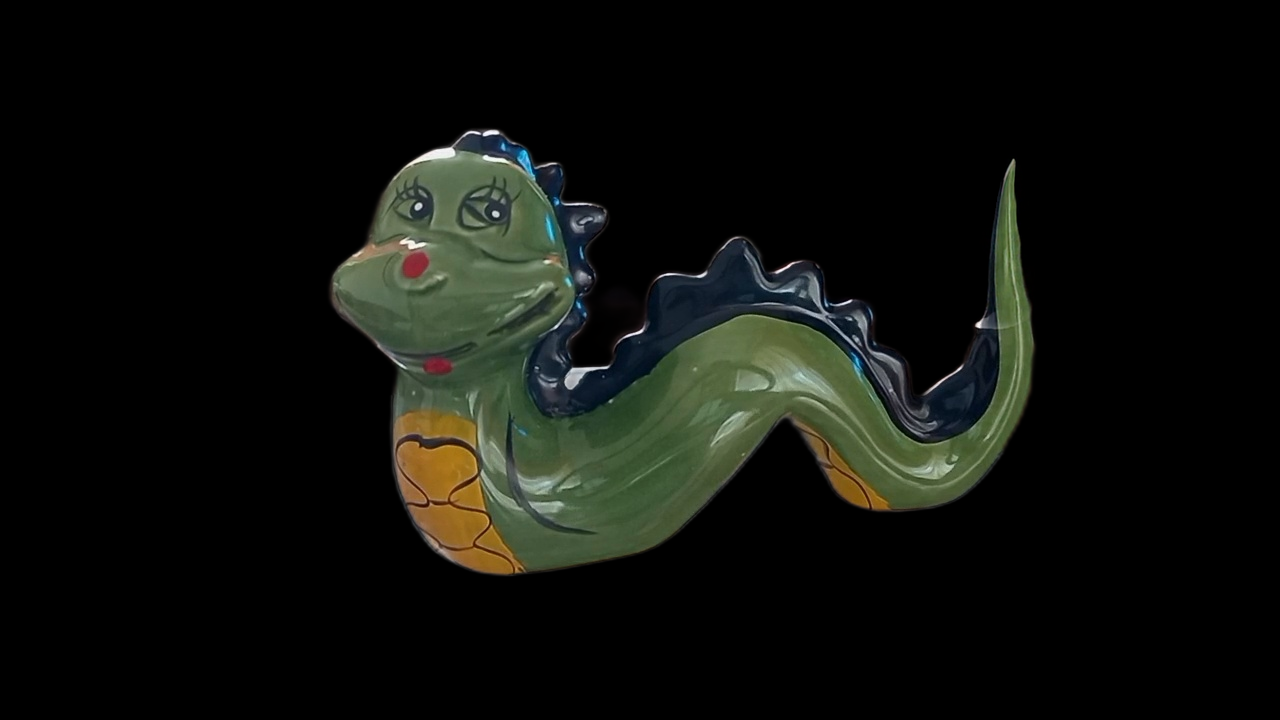

Selected candidate: /workspace/data/flux_outputs/runs/reference_fill_20260816T140151Z/selected/selected_seed_000017.png
Manifest: /workspace/data/flux_outputs/runs/reference_fill_20260816T140151Z/reference_manifest.json


In [10]:
if SELECTED_SEED not in constrained_images:
    raise ValueError(f"SELECTED_SEED must be one of {SEEDS}")

selected_path = SELECTED_DIR / f"selected_seed_{SELECTED_SEED:06d}.png"
constrained_images[SELECTED_SEED].save(selected_path)

manifest = {
    "schema_version": "fuse.reference_hypothesis.v2",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "asset_type": "synthetic_intact_reference_hypothesis",
    "authority": "human_selected_synthetic_prior_not_measured_evidence",
    "model": {
        "id": MODEL_ID,
        "pipeline": "FluxFillPipeline",
        "transformer_parameters": "12B",
        "transformer_quantization": "bitsandbytes NF4 4-bit double-quant",
        "text_encoder_2_quantization": "bitsandbytes NF4 4-bit double-quant",
        "compute_dtype": "bfloat16",
        "offload_mode": OFFLOAD_MODE,
    },
    "generation": {
        "num_inference_steps": NUM_INFERENCE_STEPS,
        "guidance_scale": GUIDANCE_SCALE,
        "max_sequence_length": MAX_SEQUENCE_LENGTH,
        "working_size": list(working_size),
        "crop_box_xyxy": list(crop_box),
        "mask_conditioned_during_generation": True,
    },
    "prompt": PROMPT,
    "input": {
        "path": str(INPUT_IMAGE),
        "sha256": sha256_file(INPUT_IMAGE),
        "size": list(source_image.size),
    },
    "mask": {
        "binary_path": str(RUN_DIR / "restoration_mask_binary.png"),
        "model_mask_path": str(RUN_DIR / "model_input_mask.png"),
        "feathered_path": str(RUN_DIR / "restoration_mask_feathered.png"),
        "editable_fraction": editable_fraction,
        "polygon_normalized": MASK_POLYGON_NORMALIZED if CUSTOM_MASK_PATH is None else None,
        "custom_mask_path": None if CUSTOM_MASK_PATH is None else str(CUSTOM_MASK_PATH),
        "outside_mask_pixels_exactly_preserved": True,
    },
    "seeds": [int(seed) for seed in SEEDS],
    "selected_seed": int(SELECTED_SEED),
    "selected_image": str(selected_path),
    "selected_sha256": sha256_file(selected_path),
    "candidate_records": candidate_records,
    "candidate_grid": str(candidate_grid_path),
    "uncertainty_proxy": str(disagreement_path),
    "previous_synthetic_used_for_generation": False,
}

manifest_path = RUN_DIR / "reference_manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

display(constrained_images[SELECTED_SEED])
print("Selected candidate:", selected_path)
print("Manifest:", manifest_path)


In [11]:
if PUBLISH_TO_HUNYUAN:
    HUNYUAN_INPUT.parent.mkdir(parents=True, exist_ok=True)
    if HUNYUAN_INPUT.exists():
        backup = HUNYUAN_INPUT.with_name(
            HUNYUAN_INPUT.stem
            + "_backup_"
            + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
            + HUNYUAN_INPUT.suffix
        )
        shutil.copy2(HUNYUAN_INPUT, backup)
        print("Backed up previous Hunyuan reference to:", backup)

    shutil.copy2(selected_path, HUNYUAN_INPUT)
    print("Published selected synthetic reference to:", HUNYUAN_INPUT)
else:
    print("Publishing is disabled.")
    print("Inspect all hypotheses, set SELECTED_SEED, then explicitly set PUBLISH_TO_HUNYUAN = True.")


Publishing is disabled.
Inspect all hypotheses, set SELECTED_SEED, then explicitly set PUBLISH_TO_HUNYUAN = True.


## Interpretation

- The generated area was conditioned on both the source crop and the
  white restoration mask.
- Pixels outside the authoritative binary mask were then restored
  exactly from the damaged photograph.
- Candidate disagreement highlights unstable synthetic geometry.
- Selection means “accepted intact-reference hypothesis,” not “verified
  original geometry.” Kaolin and the later human review remain necessary.

If 12 GB VRAM is insufficient, change `OFFLOAD_MODE` to `"sequential"`,
reduce `MODEL_MAX_SIDE` to `640`, restart the kernel and rerun. If the
first smoke test is successful, use 50 inference steps for final candidates.
